# 双向循环神经网络


## 简介
Bidirectional RNN 在每个时间步上都有正向、反向两个隐藏状态，用于能看上下文的场景。

## 原理
- 一个前向 RNN 层
- 一个反向 RNN 层
- 合并隐藏状态得到输出

![brnn](./images/birnn.svg)

$$\overrightarrow{H_t} = \overrightarrow{f} (X_t, \overrightarrow{H_{t-1}})$$
$$\overleftarrow{H_t} = \overleftarrow{f} (X_t, \overleftarrow{H_{t+1}})$$
$$O_t = g(\overrightarrow{H_t}, \overleftarrow{H_t})$$


## 实现


In [1]:
import torch
import torch.nn as nn
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
batch_size = 32
num_steps = 35
device = util.try_gpu()
train_iter, vocab = util.data.load_data_time_machine(batch_size, num_steps)
vocab_size = len(vocab)
num_hiddens = 256
num_layers = 2
num_epochs = 100
lr = 1

直接调 api，有个 `bidirectional` 参数，设置为 True 即可。不过原来的训练函数没什么意义。


困惑度 1.1, 151154.4 token/秒
time traveller the elderon the eld and to the enenterer an i s s 
traveller the ender the elderon the eld and to the enenterer


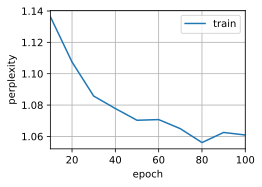

In [3]:
rnn_layer = nn.RNN(vocab_size, num_hiddens, num_layers, bidirectional=True)
model = util.model.RNNModel(rnn_layer, vocab_size).to(device)
util.train.train_ch8(model, train_iter, vocab, lr, num_epochs, device)